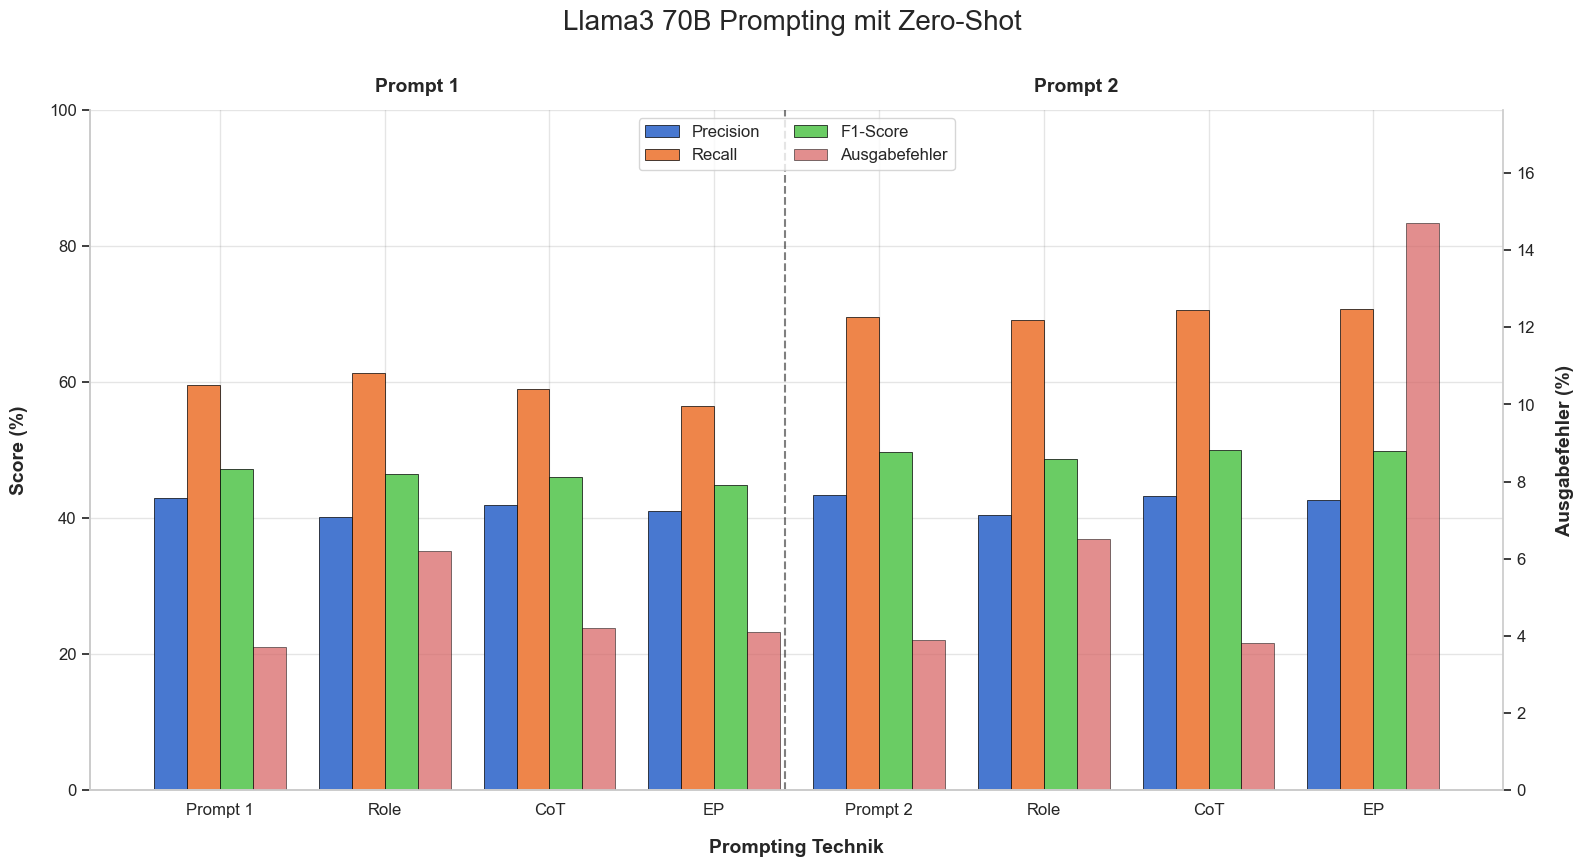

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

# Daten
prompts = ['Prompt 1', 'Role', 'CoT', 'EP', 'Prompt 2', 'Role', 'CoT', 'EP']
precision = [42.9, 40.2, 41.9, 41.0, 43.4, 40.4, 43.2, 42.7]
recall = [59.5, 61.3, 58.9, 56.5, 69.5, 69.1, 70.6, 70.7]
f1 = [47.2, 46.5, 46.0, 44.9, 49.7, 48.7, 50.0, 49.9]
errors = [3.7, 6.2, 4.2, 4.1, 3.9, 6.5, 3.8, 14.7]

# Erstellen der Figur und Achsen
fig, ax1 = plt.subplots(figsize=(16, 10))

# Wissenschaftliche Farbpalette
colors = ['#4878D0', '#EE854A', '#6ACC64', '#D65F5F']

# Breite der Balken
bar_width = 0.2

# Position der Balken
r1 = np.arange(len(prompts))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Plotten der Daten
ax1.bar(r1, precision, color=colors[0], width=bar_width, label='Precision', edgecolor='black', linewidth=0.5)
ax1.bar(r2, recall, color=colors[1], width=bar_width, label='Recall', edgecolor='black', linewidth=0.5)
ax1.bar(r3, f1, color=colors[2], width=bar_width, label='F1-Score', edgecolor='black', linewidth=0.5)

# Zweite Y-Achse für Fehler
ax2 = ax1.twinx()
ax2.bar(r4, errors, color=colors[3], width=bar_width, label='Ausgabefehler', alpha=0.7, edgecolor='black', linewidth=0.5)

# Achsentitel und Legende
ax1.set_ylabel('Score (%)', fontsize=14, labelpad=15, fontweight='bold')
ax2.set_ylabel('Ausgabefehler (%)', fontsize=14, labelpad=15, fontweight='bold' )
ax1.set_xlabel('Prompting Technik', fontsize=14, labelpad=15, fontweight='bold')

# Kombinierte Legende
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=2, fontsize=12)

# Titel
fig.suptitle('Llama3 70B Prompting mit Zero-Shot', fontsize=20, y=0.98)

# X-Achsen-Labels
plt.xticks([r + 1.5 * bar_width for r in range(len(prompts))], prompts, rotation=45, ha='right', fontsize=20, fontweight='bold')

# Gitternetzlinien
ax1.grid(True, axis='both', linestyle='-', alpha=0.2, color='gray')
ax2.grid(False)  # Deaktivieren des Gitters für die zweite Y-Achse

# Entfernen der oberen und rechten Achsenlinien
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Anpassen der Y-Achsen
ax1.set_ylim(0, 100)
ax2.set_ylim(0, max(errors) * 1.2)

# Hinzufügen einer gestrichelten Linie zwischen Prompt 1 und Prompt 2
ax1.axvline(x=3.73, color='black', linestyle='--', alpha=0.5)

# Beschriftungen für Prompt 1 und Prompt 2
ax1.text(1.5, ax1.get_ylim()[1] * 1.02, 'Prompt 1', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax1.text(5.5, ax1.get_ylim()[1] * 1.02, 'Prompt 2', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Tick-Größe anpassen
ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.2)

# Als PDF speichern
with PdfPages('prompt_technik.pdf') as pdf:
    pdf.savefig(fig, bbox_inches='tight')

plt.show()